### Step 1: Setup and Data Loading

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
!pip install langchain langchain-community pypdf2 python-dotenv openai tiktoken

& was unexpected at this time.
The value specified in an AutoRun registry key could not be parsed.


In [3]:
!pip uninstall -y whisper
!pip install -U openai-whisper

& was unexpected at this time.
The value specified in an AutoRun registry key could not be parsed.


& was unexpected at this time.
The value specified in an AutoRun registry key could not be parsed.


In [4]:
!pip install imageio-ffmpeg

   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   - -------------------------------------- 0.8/31.2 MB 5.6 MB/s eta 0:00:06
   -- ------------------------------------- 2.1/31.2 MB 5.6 MB/s eta 0:00:06
   ---- ----------------------------------- 3.7/31.2 MB 6.4 MB/s eta 0:00:05
   ------ --------------------------------- 4.7/31.2 MB 6.2 MB/s eta 0:00:05
   -------- ------------------------------- 6.3/31.2 MB 6.4 MB/s eta 0:00:04
   ---------- ----------------------------- 7.9/31.2 MB 6.5 MB/s eta 0:00:04
   ----------- ---------------------------- 9.2/31.2 MB 6.6 MB/s eta 0:00:04
   ------------- -------------------------- 10.7/31.2 MB 6.5 MB/s eta 0:00:04
   --------------- ------------------------ 12.3/31.2 MB 6.7 MB/s eta 0:00:03
   ----------------- ---------------------- 13.9/31.2 MB 6.8 MB/s eta 0:00:03
   ------------------- -------------------- 15.5/31.2 MB 6.9 MB/s eta 0:00:03
   ---------------------- ----------------- 17.3/31.2 MB 7.0 MB/s eta 0:00:02
 

& was unexpected at this time.
The value specified in an AutoRun registry key could not be parsed.


In [5]:
from pathlib import Path
from dotenv import load_dotenv
from pypdf import PdfReader
import os

load_dotenv()

# File paths
audio_path = Path("Joyce_Meyer_Podcast.wav").resolve()
pdf_path = Path("joyce_meyer_sermon.pdf").resolve()

print("Audio exists:", audio_path.exists())
print("PDF exists:", pdf_path.exists())
print("Audio path:", audio_path)
print("PDF path:", pdf_path)

# Load PDF text
reader = PdfReader(str(pdf_path))
pdf_text = ""

for page in reader.pages:
    page_text = page.extract_text()
    if page_text:
        pdf_text += page_text + "\n"

print("\nPDF loaded successfully")
print("Pages:", len(reader.pages))
print("PDF characters:", len(pdf_text))
print("PDF preview:")
print(pdf_text[:300])

# Transcribe podcast audio
# Uses OpenAI Whisper if OPENAI_API_KEY is available, otherwise local Whisper
podcast_text = ""

if os.getenv("OPENAI_API_KEY"):
    from openai import OpenAI
    client = OpenAI()

    with audio_path.open("rb") as audio_file:
        result = client.audio.transcriptions.create(
            model="whisper-1",
            file=audio_file,
        )
    podcast_text = result.text
else:
    import whisper

    model = whisper.load_model("tiny")
    result = model.transcribe(str(audio_path), fp16=False)
    podcast_text = result["text"]

print("\nPodcast transcribed successfully")
print("Podcast characters:", len(podcast_text))
print("Podcast preview:")
print(podcast_text[:300])


Audio exists: True
PDF exists: True
Audio path: C:\Users\Denish\Desktop\TA\AC_bootcamp\Yeon\Lab 5_Different Ways to Chunk Podcast and PDF\Lab_Chunk-Podcast-and-PDF\Joyce_Meyer_Podcast.wav
PDF path: C:\Users\Denish\Desktop\TA\AC_bootcamp\Yeon\Lab 5_Different Ways to Chunk Podcast and PDF\Lab_Chunk-Podcast-and-PDF\joyce_meyer_sermon.pdf

PDF loaded successfully
Pages: 31
PDF characters: 51683
PDF preview:
Joyce  Meyer  
 
 
 
 
 
 
 
HOW  DOES  FAITH   WORK?   
 
 
 
 
 
 
 
Transcribed  and  edited  by  livingsermons.com  
1   
Title:  How  Does  Faith  Works  Author:  Joyce  Meyer  Publisher:  Livingsermons.com  ©  2025  Joyce  Meyer/  Livingsermons.com  
 
All  rights  reserved.  No  portion  of  

Podcast transcribed successfully
Podcast characters: 4738
Podcast preview:
 on Air Celebrating 40 Years of Radio. We invite you to join us. Joyce Meyer. For a Minute Read. It's been 40 years since Joyce's voice first hit the air waves on W. Speed W in St. Louis, Missouri, a 15-minute air sl

Step 2: Fixed-size chunking

In [7]:
from langchain_text_splitters import CharacterTextSplitter
import pandas as pd

chunk_sizes = [500, 1000, 2000]
overlaps = [0, 50, 100]

results = []

for size in chunk_sizes:
    for overlap in overlaps:
        splitter = CharacterTextSplitter(
            separator=" ",
            chunk_size=size,
            chunk_overlap=overlap,
            length_function=len
        )

        pdf_chunks = splitter.split_text(pdf_text)
        podcast_chunks = splitter.split_text(podcast_text)

        results.append({
            "chunk_size": size,
            "overlap": overlap,
            "pdf_chunks": len(pdf_chunks),
            "podcast_chunks": len(podcast_chunks),
            "pdf_sample": pdf_chunks[0][:120] if pdf_chunks else "",
            "podcast_sample": podcast_chunks[0][:120] if podcast_chunks else ""
        })

df_results = pd.DataFrame(results)
display(df_results)

# Keep the standard 1000/100 setting for later steps
standard_splitter = CharacterTextSplitter(
    separator=" ",
    chunk_size=1000,
    chunk_overlap=100,
    length_function=len
)
pdf_chunks_fixed = standard_splitter.split_text(pdf_text)
podcast_chunks_fixed = standard_splitter.split_text(podcast_text)

print("Saved reference chunks:")
print("pdf_chunks_fixed:", len(pdf_chunks_fixed))
print("podcast_chunks_fixed:", len(podcast_chunks_fixed))


c:\Users\Denish\anaconda1\envs\lab\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,chunk_size,overlap,pdf_chunks,podcast_chunks,pdf_sample,podcast_sample
0,500,0,96,10,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES FA...,on Air Celebrating 40 Years of Radio. We invit...
1,500,50,107,11,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES FA...,on Air Celebrating 40 Years of Radio. We invit...
2,500,100,120,12,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES FA...,on Air Celebrating 40 Years of Radio. We invit...
3,1000,0,48,5,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES FA...,on Air Celebrating 40 Years of Radio. We invit...
4,1000,50,51,5,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES FA...,on Air Celebrating 40 Years of Radio. We invit...
5,1000,100,54,6,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES FA...,on Air Celebrating 40 Years of Radio. We invit...
6,2000,0,24,3,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES FA...,on Air Celebrating 40 Years of Radio. We invit...
7,2000,50,25,3,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES FA...,on Air Celebrating 40 Years of Radio. We invit...
8,2000,100,26,3,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES FA...,on Air Celebrating 40 Years of Radio. We invit...


Saved reference chunks:
pdf_chunks_fixed: 54
podcast_chunks_fixed: 6


Conclusion Step 2: Fixed-size chunking is simple and fast, but it often breaks sentences in the middle because it splits text only by character count. It also does not handle paragraph boundaries very well, so chunks can look awkward or cut across ideas. In this comparison, the PDF handles fixed-size chunking better than the podcast transcript because the PDF text is more organized and has clearer structure, while the podcast transcript is more conversational and tends to produce less clean chunks.

### Step 3: Recursive Character Chunking

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
import pandas as pd

# Recursive chunking tries to keep paragraphs/sentences together better than fixed-size chunking
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)

pdf_chunks_recursive = recursive_splitter.split_text(pdf_text)
podcast_chunks_recursive = recursive_splitter.split_text(podcast_text)

print("PDF recursive chunks:", len(pdf_chunks_recursive))
print("Podcast recursive chunks:", len(podcast_chunks_recursive))

print("\nPDF first chunk:")
print(pdf_chunks_recursive[0][:500] if pdf_chunks_recursive else "No chunks")

print("\nPodcast first chunk:")
print(podcast_chunks_recursive[0][:500] if podcast_chunks_recursive else "No chunks")


PDF recursive chunks: 66
Podcast recursive chunks: 6

PDF first chunk:
Joyce  Meyer  
 
 
 
 
 
 
 
HOW  DOES  FAITH   WORK?   
 
 
 
 
 
 
 
Transcribed  and  edited  by  livingsermons.com  
1   
Title:  How  Does  Faith  Works  Author:  Joyce  Meyer  Publisher:  Livingsermons.com  ©  2025  Joyce  Meyer/  Livingsermons.com  
 
All  rights  reserved.  No  portion  of  this  book  may  be  reproduced,  stored  in  a  retrieval  system,  or  transmitted  in  any  
form
 
or
 
by
 
any
 
means—electronic,
 
mechanical,
 
photocopying,
 
recording,
 
scanning,
 
or
 
o

Podcast first chunk:
on Air Celebrating 40 Years of Radio. We invite you to join us. Joyce Meyer. For a Minute Read. It's been 40 years since Joyce's voice first hit the air waves on W. Speed W in St. Louis, Missouri, a 15-minute air slot that God would use to help pave the way for an international media ministry. It all began in 1982. As a associate pastor at Life Christian Church, Joyce taught a women's Bible study and at

In [9]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
import pandas as pd

chunk_sizes = [500, 1000, 2000]
overlaps = [0, 50, 100]

results = []

for size in chunk_sizes:
    for overlap in overlaps:
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=size,
            chunk_overlap=overlap,
            length_function=len,
            separators=["\n\n", "\n", ". ", " ", ""]
        )

        pdf_chunks = splitter.split_text(pdf_text)
        podcast_chunks = splitter.split_text(podcast_text)

        results.append({
            "chunk_size": size,
            "overlap": overlap,
            "pdf_chunks": len(pdf_chunks),
            "podcast_chunks": len(podcast_chunks),
            "pdf_sample": pdf_chunks[0][:120] if pdf_chunks else "",
            "podcast_sample": podcast_chunks[0][:120] if podcast_chunks else ""
        })

df_recursive = pd.DataFrame(results)
display(df_recursive)


,chunk_size,overlap,pdf_chunks,podcast_chunks,pdf_sample,podcast_sample
0,500,0,109,11,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES...,on Air Celebrating 40 Years of Radio. We invit...
1,500,50,119,11,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES...,on Air Celebrating 40 Years of Radio. We invit...
2,500,100,128,12,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES...,on Air Celebrating 40 Years of Radio. We invit...
3,1000,0,54,5,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES...,on Air Celebrating 40 Years of Radio. We invit...
4,1000,50,56,6,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES...,on Air Celebrating 40 Years of Radio. We invit...
5,1000,100,58,6,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES...,on Air Celebrating 40 Years of Radio. We invit...
6,2000,0,27,3,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES...,on Air Celebrating 40 Years of Radio. We invit...
7,2000,50,27,3,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES...,on Air Celebrating 40 Years of Radio. We invit...
8,2000,100,28,3,Joyce Meyer \n \n \n \n \n \n \n \nHOW DOES...,on Air Celebrating 40 Years of Radio. We invit...


Conclusion step 3: Recursive chunking does preserve sentence boundaries better than fixed-size chunking because it tries to split on larger natural boundaries first, such as paragraphs and sentences. For the podcast, it handles the conversational structure better than fixed-size chunking, but it can still produce uneven chunks because spoken language is less structured and often contains long, flowing sentences. For the PDF, it respects section headers and paragraph boundaries much better, so the chunks are usually cleaner and more meaningful.

### Step 4: Token-Based Chunking


In [10]:
# Token-based chunking
from langchain_text_splitters import TokenTextSplitter


token_splitter = TokenTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

pdf_chunks_tokens = token_splitter.split_text(pdf_text)
podcast_chunks_tokens = token_splitter.split_text(podcast_text)

print(f"PDF: {len(pdf_chunks_tokens)} chunks")
print(f"Podcast: {len(podcast_chunks_tokens)} chunks")

# Compare actual token counts - IMPORTANT!
import tiktoken
encoding = tiktoken.get_encoding("cl100k_base")

for i, chunk in enumerate(pdf_chunks_tokens[:3]):
    token_count = len(encoding.encode(chunk))
    print(f"Chunk {i+1}: {token_count} tokens, {len(chunk)} characters")


PDF: 57 chunks
Podcast: 3 chunks
Chunk 1: 338 tokens, 1120 characters
Chunk 2: 322 tokens, 1057 characters
Chunk 3: 302 tokens, 982 characters


### Step 5: Semantic Chunking (Optional - Advanced)

In [11]:
!pip install -q sentence-transformers numpy


& was unexpected at this time.
The value specified in an AutoRun registry key could not be parsed.


In [12]:
# Semantic chunking (optional advanced approach)
from sentence_transformers import SentenceTransformer
import numpy as np
 
model = SentenceTransformer('all-MiniLM-L6-v2')
 
def semantic_chunk(text, threshold=0.7):
    """Split text based on semantic similarity between sentences"""
    sentences = text.split('. ')
    if len(sentences) < 2:
        return [text]
    
    embeddings = model.encode(sentences)
    chunks = []
    current_chunk = [sentences[0]]
    
    for i in range(1, len(sentences)):
        similarity = np.dot(embeddings[i-1], embeddings[i])
        if similarity < threshold:
            chunks.append('. '.join(current_chunk))
            current_chunk = [sentences[i]]
        else:
            current_chunk.append(sentences[i])
    
    if current_chunk:
        chunks.append('. '.join(current_chunk))
    
    return chunks
 
# TIP: Apply to a sample (semantic chunking can be slow on large texts)
pdf_sample = pdf_text[:5000]  # First 5000 chars
pdf_chunks_semantic = semantic_chunk(pdf_sample)
print(f"Semantic chunks from sample: {len(pdf_chunks_semantic)}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 934.69it/s]


Semantic chunks from sample: 7


### Step 6: Visualize and Compare Results

In [13]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


& was unexpected at this time.
The value specified in an AutoRun registry key could not be parsed.


,Strategy,PDF Chunk Count,Podcast Chunk Count,PDF Avg Length,Podcast Avg Length
0,Fixed-Size,54,6,978.851852,870.666667
1,Recursive,66,6,958.424242,918.333333
2,Token-Based,57,3,1005.631579,1746.333333


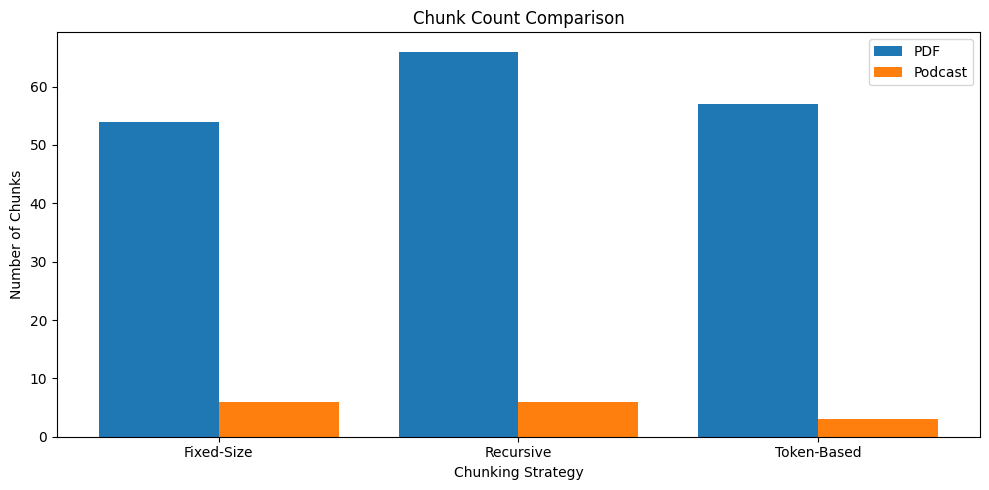

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

required_vars = [
    "pdf_chunks_fixed",
    "podcast_chunks_fixed",
    "pdf_chunks_recursive",
    "podcast_chunks_recursive",
    "pdf_chunks_tokens",
    "podcast_chunks_tokens",
]

missing = [var for var in required_vars if var not in globals()]
if missing:
    print("Missing variables:", missing)
    print("Run Steps 2, 3, and 4 first.")
else:
    comparison_data = {
        "Strategy": ["Fixed-Size", "Recursive", "Token-Based"],
        "PDF Chunk Count": [
            len(pdf_chunks_fixed),
            len(pdf_chunks_recursive),
            len(pdf_chunks_tokens)
        ],
        "Podcast Chunk Count": [
            len(podcast_chunks_fixed),
            len(podcast_chunks_recursive),
            len(podcast_chunks_tokens)
        ],
        "PDF Avg Length": [
            sum(len(c) for c in pdf_chunks_fixed) / len(pdf_chunks_fixed),
            sum(len(c) for c in pdf_chunks_recursive) / len(pdf_chunks_recursive),
            sum(len(c) for c in pdf_chunks_tokens) / len(pdf_chunks_tokens)
        ],
        "Podcast Avg Length": [
            sum(len(c) for c in podcast_chunks_fixed) / len(podcast_chunks_fixed),
            sum(len(c) for c in podcast_chunks_recursive) / len(podcast_chunks_recursive),
            sum(len(c) for c in podcast_chunks_tokens) / len(podcast_chunks_tokens)
        ]
    }

    df_compare = pd.DataFrame(comparison_data)
    display(df_compare)

    plt.figure(figsize=(10, 5))
    x = range(len(df_compare["Strategy"]))
    plt.bar([i - 0.2 for i in x], df_compare["PDF Chunk Count"], width=0.4, label="PDF")
    plt.bar([i + 0.2 for i in x], df_compare["Podcast Chunk Count"], width=0.4, label="Podcast")
    plt.xticks(x, df_compare["Strategy"])
    plt.xlabel("Chunking Strategy")
    plt.ylabel("Number of Chunks")
    plt.title("Chunk Count Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


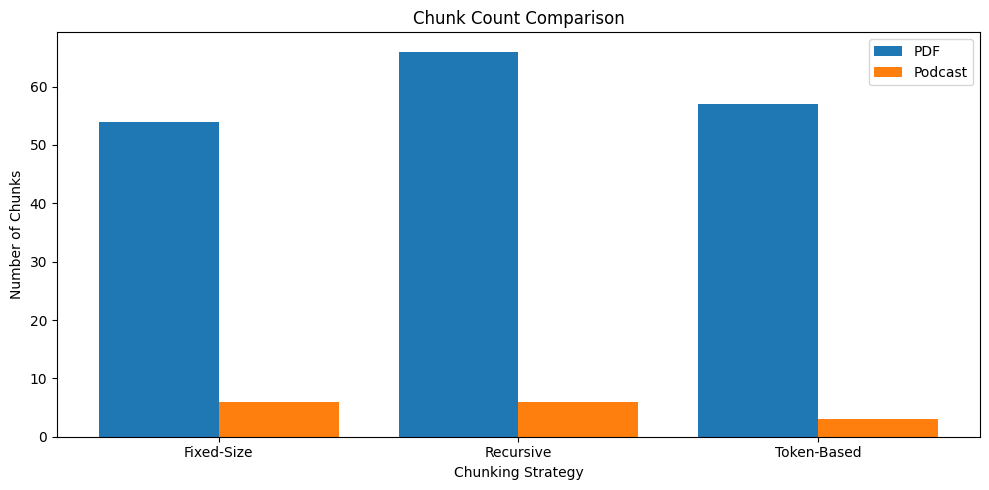

In [15]:
# Visualize chunk count comparison
plt.figure(figsize=(10, 5))
x = range(len(df_compare["Strategy"]))

plt.bar([i - 0.2 for i in x], df_compare["PDF Chunk Count"], width=0.4, label="PDF")
plt.bar([i + 0.2 for i in x], df_compare["Podcast Chunk Count"], width=0.4, label="Podcast")

plt.xticks(x, df_compare["Strategy"])
plt.xlabel("Chunking Strategy")
plt.ylabel("Number of Chunks")
plt.title("Chunk Count Comparison")
plt.legend()
plt.tight_layout()
plt.show()


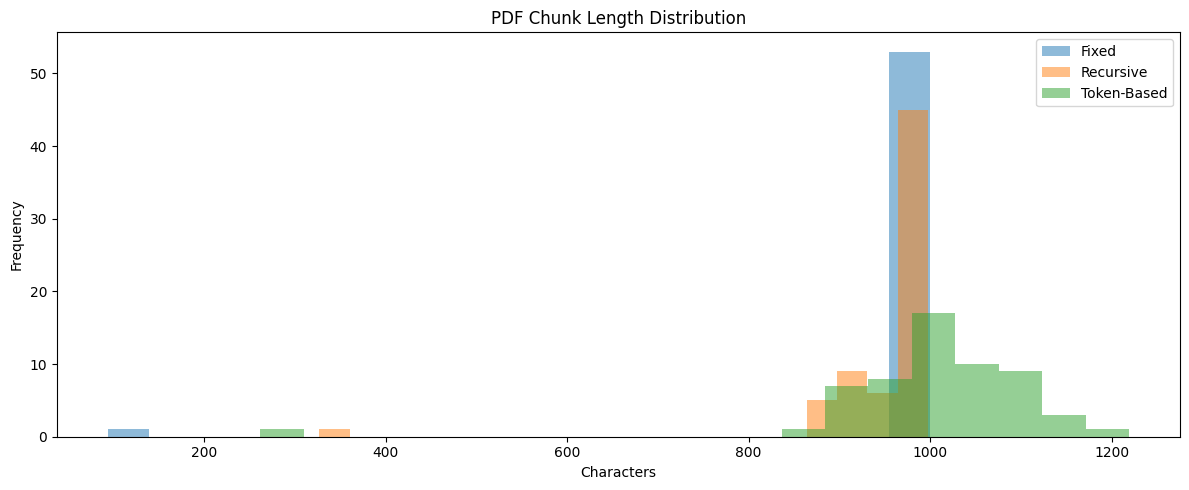

In [16]:
# Visualize chunk length distributions for PDF
plt.figure(figsize=(12, 5))
plt.hist([len(c) for c in pdf_chunks_fixed], bins=20, alpha=0.5, label="Fixed")
plt.hist([len(c) for c in pdf_chunks_recursive], bins=20, alpha=0.5, label="Recursive")
plt.hist([len(c) for c in pdf_chunks_tokens], bins=20, alpha=0.5, label="Token-Based")
plt.title("PDF Chunk Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


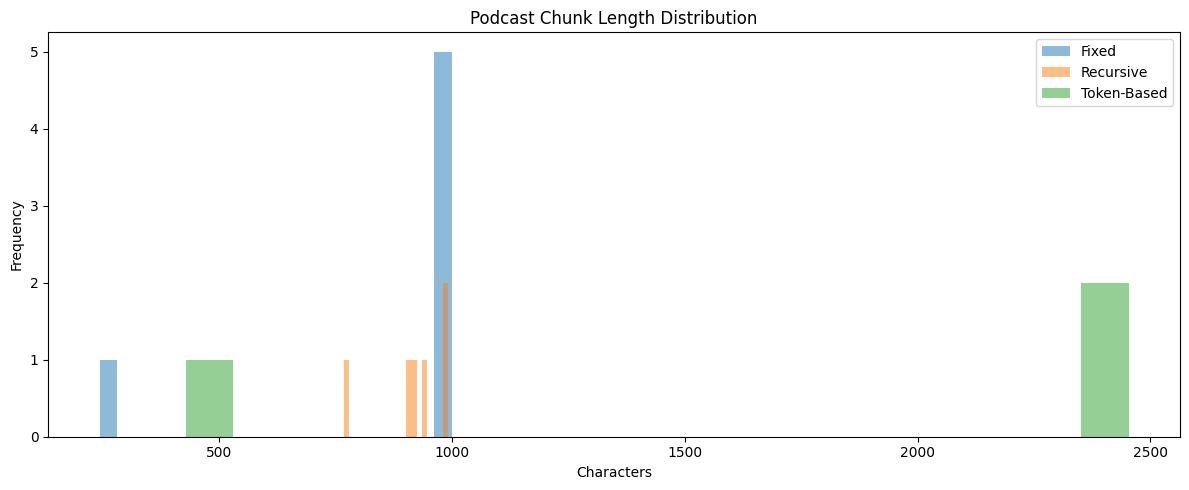

In [17]:
# Visualize chunk length distributions for Podcast
plt.figure(figsize=(12, 5))
plt.hist([len(c) for c in podcast_chunks_fixed], bins=20, alpha=0.5, label="Fixed")
plt.hist([len(c) for c in podcast_chunks_recursive], bins=20, alpha=0.5, label="Recursive")
plt.hist([len(c) for c in podcast_chunks_tokens], bins=20, alpha=0.5, label="Token-Based")
plt.title("Podcast Chunk Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


### Step 7: Analyze Chunk Quality

In [18]:
def analyze_boundaries(chunks, name):
    if not chunks:
        print(f"{name}: no chunks to analyze.")
        return

    sentence_endings = sum(1 for c in chunks if c.strip().endswith((".", "!", "?")))
    paragraph_breaks = sum(1 for c in chunks if "\n\n" in c or "\n" in c)

    print(f"{name}:")
    print(f"  Chunks: {len(chunks)}")
    print(f"  Sentence boundary endings: {sentence_endings / len(chunks) * 100:.1f}%")
    print(f"  Paragraph-like breaks: {paragraph_breaks / len(chunks) * 100:.1f}%")

print("--- Quality Analysis ---")
analyze_boundaries(pdf_chunks_fixed, "PDF Fixed")
analyze_boundaries(pdf_chunks_recursive, "PDF Recursive")
analyze_boundaries(pdf_chunks_tokens, "PDF Token-Based")
analyze_boundaries(podcast_chunks_fixed, "Podcast Fixed")
analyze_boundaries(podcast_chunks_recursive, "Podcast Recursive")
analyze_boundaries(podcast_chunks_tokens, "Podcast Token-Based")


--- Quality Analysis ---
PDF Fixed:
  Chunks: 54
  Sentence boundary endings: 3.7%
  Paragraph-like breaks: 100.0%
PDF Recursive:
  Chunks: 66
  Sentence boundary endings: 24.2%
  Paragraph-like breaks: 100.0%
PDF Token-Based:
  Chunks: 57
  Sentence boundary endings: 8.8%
  Paragraph-like breaks: 100.0%
Podcast Fixed:
  Chunks: 6
  Sentence boundary endings: 16.7%
  Paragraph-like breaks: 0.0%
Podcast Recursive:
  Chunks: 6
  Sentence boundary endings: 16.7%
  Paragraph-like breaks: 0.0%
Podcast Token-Based:
  Chunks: 3
  Sentence boundary endings: 33.3%
  Paragraph-like breaks: 0.0%


Step 8: Make Recommendations

In [19]:
summary = pd.DataFrame({
    "Strategy": ["Fixed-Size", "Recursive", "Token-Based"],
    "PDF": [
        "Fast, but may cut sentences and ignore structure",
        "Best balance of structure and readability",
        "Good for model input, but not always natural boundaries"
    ],
    "Podcast": [
        "Often messy because speech is unstructured",
        "Better than fixed-size, but still imperfect",
        "Usually best for long spoken transcript text"
    ]
})

display(summary)


,Strategy,PDF,Podcast
0,Fixed-Size,"Fast, but may cut sentences and ignore structure",Often messy because speech is unstructured
1,Recursive,Best balance of structure and readability,"Better than fixed-size, but still imperfect"
2,Token-Based,"Good for model input, but not always natural b...",Usually best for long spoken transcript text
